📊 Project FORESIGHT
AI-Powered Demand & Inventory Intelligence Platform

# Notebook 06: Model Evaluation

### 📌 Project Information

| Item | Details |
|---|---|
| Author | Mohit Kumar |
| Internship | Zidio Development |
| Project Type | End-to-End Data Analytics & Machine Learning Project |
| Notebook Version | 1.0 |
| Status | In Progress |
| Last Updated | August 2026 |


## 🎯 1. Business Context and Notebook Objective

Notebook 04 locked a statistical baseline champion (`damped_trend_exponential_smoothing`,
final-test WAPE 53.17%, bias +10.94%). Notebook 05 independently locked an ML champion under
the identical evaluation design. Neither notebook was permitted to compare itself against the
other using final-test evidence — that comparison, and the resulting production decision,
belongs entirely to this notebook.

This notebook will:

- load both locked champion configurations and their untouched final-test results;
- compare the two champions **on final-test evidence only**, never on validation;
- apply a pre-declared, objective decision rule rather than picking the "nicer-looking" model;
- run a paired significance check as supporting evidence, not just an aggregate WAPE difference;
- examine where each model wins or loses (by horizon and by product segment);
- **select and lock the single production forecaster**, honestly reporting the outcome even if
  the baseline wins;
- assemble the one canonical forecast dataset Notebook 07 will consume.

> **Scope boundary:** This notebook does not train any new model, does not re-run validation,
> and does not perform inventory or risk scoring. It consumes only the already-locked outputs
> of Notebooks 04 and 05, and its own output is the single production forecast handed to
> Notebook 07.

> **Non-negotiable rule (carried forward from the engagement brief):** *"If a complex model
> can't beat seasonal-naive on backtest, ship the baseline and say why."* The same discipline
> applies here — the ML champion is only selected if it demonstrates a **credible**, not
> marginal, improvement on the untouched final test.


## ⚙️ 2. Setup and Notebook 04 & 05 Handoff

### 2.1 Environment, Paths and Input Loading

Both locked champion configurations and their final-test artefacts are loaded. No validation-fold
data is loaded in this notebook — only what each notebook produced from its untouched final test.


In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Environment setup completed successfully.")
print(f"SciPy available for significance testing: {SCIPY_AVAILABLE}")


Environment setup completed successfully.
SciPy available for significance testing: True


In [2]:
# ============================================================
# Resolve Project Paths (same convention as Notebooks 00-05)
# ============================================================

CURRENT_DIRECTORY = Path.cwd()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
BASELINE_OUTPUTS_DIR = PROCESSED_DATA_DIR / "baseline_outputs"
ML_OUTPUTS_DIR = PROCESSED_DATA_DIR / "ml_outputs"
PRODUCTION_OUTPUTS_DIR = PROCESSED_DATA_DIR / "production_outputs"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

for directory_path in [PRODUCTION_OUTPUTS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory_path.mkdir(parents=True, exist_ok=True)

# Notebook 04 (baseline) final-test artefacts
BASELINE_CHAMPION_CONFIG_FILE = BASELINE_OUTPUTS_DIR / "04_champion_baseline_config.json"
BASELINE_SKU_METRICS_FILE = BASELINE_OUTPUTS_DIR / "04_baseline_sku_metrics.csv"
BASELINE_FORECASTS_FILE = BASELINE_OUTPUTS_DIR / "04_baseline_forecasts.csv"

# Notebook 05 (ML) final-test artefacts
ML_CHAMPION_CONFIG_FILE = ML_OUTPUTS_DIR / "05_champion_ml_config.json"
ML_FORECASTS_FILE = ML_OUTPUTS_DIR / "05_ml_forecasts.csv"

# SKU master (for segment-level comparison in Section 4.3)
SKU_MASTER_FILE = PROCESSED_DATA_DIR / "sku_master_final.csv"

print("Baseline champion config:", BASELINE_CHAMPION_CONFIG_FILE)
print("ML champion config:", ML_CHAMPION_CONFIG_FILE)


Baseline champion config: C:\Users\hp\Project FORESIGHT\data\processed\baseline_outputs\04_champion_baseline_config.json
ML champion config: C:\Users\hp\Project FORESIGHT\data\processed\ml_outputs\05_champion_ml_config.json


In [3]:
# ============================================================
# Load Locked Champion Configurations
# ============================================================

with open(BASELINE_CHAMPION_CONFIG_FILE, "r") as f:
    baseline_config = json.load(f)

with open(ML_CHAMPION_CONFIG_FILE, "r") as f:
    ml_config = json.load(f)

print("Baseline champion:", baseline_config.get("candidate"))
print("Baseline final-test WAPE:", baseline_config.get("final_test", {}).get("wape",
      "see 04_baseline_final_test_overall_metrics.csv if not embedded in config"))
print()
print("ML champion:", ml_config.get("champion_model"))
print("ML final-test WAPE:", ml_config.get("final_test_wape"))
print("ML final-test Bias:", ml_config.get("final_test_bias"))


Baseline champion: damped_trend_exponential_smoothing
Baseline final-test WAPE: see 04_baseline_final_test_overall_metrics.csv if not embedded in config

ML champion: lightgbm_default
ML final-test WAPE: 59.34
ML final-test Bias: 11.03


In [4]:
# ============================================================
# Load Final-Test Scored Datasets
# ============================================================
#
# NOTE ON SCHEMA: this cell auto-detects the actual/forecast/date/series column names in
# each file rather than assuming fixed names, since the two files were produced by different
# notebooks. Review the printed column lists below - if auto-detection prints a warning,
# set the corresponding *_COL constant manually before continuing.

ml_final_test = pd.read_csv(ML_FORECASTS_FILE, parse_dates=["week_start_date"])
print("ML final-test file columns:", list(ml_final_test.columns))

# Try the SKU-level metrics file first for the baseline (it is already scoped to the
# champion's final test, per Notebook 04 Section 6.1). Fall back to filtering the full
# forecasts file if the SKU metrics file does not contain row-level actual/forecast values.
baseline_sku_metrics_raw = pd.read_csv(BASELINE_SKU_METRICS_FILE)
print("\nBaseline SKU-metrics file columns:", list(baseline_sku_metrics_raw.columns))

baseline_has_row_level_values = any(
    c.lower() in ("actual", "actual_demand", "predicted", "forecast", "predicted_demand")
    for c in baseline_sku_metrics_raw.columns
)

if baseline_has_row_level_values:
    baseline_final_test = baseline_sku_metrics_raw.copy()
    print("\nUsing 04_baseline_sku_metrics.csv directly (row-level values detected).")
else:
    print("\n04_baseline_sku_metrics.csv appears to hold aggregated error metrics only.")
    print("Falling back to 04_baseline_forecasts.csv, filtered to the champion and final-test stage.")
    baseline_forecasts_raw = pd.read_csv(BASELINE_FORECASTS_FILE)
    print("Full baseline forecasts file columns:", list(baseline_forecasts_raw.columns))

    candidate_col = next((c for c in baseline_forecasts_raw.columns
                           if "candidate" in c.lower() or "model" in c.lower()), None)
    stage_col = next((c for c in baseline_forecasts_raw.columns
                       if "stage" in c.lower() or "split" in c.lower() or "fold" in c.lower()), None)

    assert candidate_col is not None and stage_col is not None, (
        "Could not auto-detect the candidate/stage columns in 04_baseline_forecasts.csv - "
        "set candidate_col and stage_col manually by inspecting the printed column list above."
    )

    champion_name = baseline_config.get("candidate", "damped_trend_exponential_smoothing")
    baseline_final_test = baseline_forecasts_raw[
        (baseline_forecasts_raw[candidate_col] == champion_name)
        & (baseline_forecasts_raw[stage_col].astype(str).str.contains("final", case=False))
    ].copy()

print(f"\nBaseline final-test records: {len(baseline_final_test):,}")
print(f"ML final-test records: {len(ml_final_test):,}")


ML final-test file columns: ['sku_id', 'week_start_date', 'horizon', 'predicted_demand', 'weekly_units_sold']

Baseline SKU-metrics file columns: ['evaluation_stage', 'candidate', 'sku_id', 'forecast_records', 'actual_demand_total', 'predicted_demand_total', 'absolute_error_total', 'squared_error_total', 'forecast_error_total', 'wape_pct', 'bias_pct', 'mae', 'rmse']

04_baseline_sku_metrics.csv appears to hold aggregated error metrics only.
Falling back to 04_baseline_forecasts.csv, filtered to the champion and final-test stage.
Full baseline forecasts file columns: ['evaluation_stage', 'candidate', 'split_id', 'forecast_origin', 'horizon', 'sku_id', 'week_start_date', 'actual_demand', 'predicted_demand', 'forecast_error', 'absolute_error', 'squared_error']

Baseline final-test records: 2,400
ML final-test records: 2,400


### 2.2 Minimal Input Readiness Check

Both final-test datasets must cover the identical series, identical horizon, and identical
evaluation window before any comparison is valid — otherwise a WAPE difference could simply
reflect different coverage, not different accuracy.


In [5]:
# ============================================================
# Cross-Notebook Consistency Checks
# ============================================================

readiness_checks = []

readiness_checks.append({
    "Check": "Baseline configuration is LOCKED",
    "Observed Result": baseline_config.get("configuration_status", "unknown"),
    "Required Result": "LOCKED",
    "Status": "PASS" if str(baseline_config.get("configuration_status", "")).upper() == "LOCKED" else "FAIL",
})

readiness_checks.append({
    "Check": "ML configuration is LOCKED",
    "Observed Result": ml_config.get("configuration_status", "unknown"),
    "Required Result": "LOCKED",
    "Status": "PASS" if str(ml_config.get("configuration_status", "")).upper() == "LOCKED" else "FAIL",
})

readiness_checks.append({
    "Check": "Matching final-test window",
    "Observed Result": f"baseline={baseline_config.get('final_test_start')}, ml={ml_config.get('final_test_start')}",
    "Required Result": "Identical start dates",
    "Status": "PASS" if baseline_config.get("final_test_start") == ml_config.get("final_test_start") else "FAIL",
})

readiness_checks.append({
    "Check": "Matching forecast horizon",
    "Observed Result": f"baseline={baseline_config.get('forecast_horizon_weeks')}, ml={ml_config.get('forecast_horizon_weeks')}",
    "Required Result": "Identical horizon",
    "Status": "PASS" if baseline_config.get("forecast_horizon_weeks") == ml_config.get("forecast_horizon_weeks") else "FAIL",
})

readiness_checks.append({
    "Check": "Comparable record volume",
    "Observed Result": f"baseline={len(baseline_final_test):,}, ml={len(ml_final_test):,}",
    "Required Result": "Same order of magnitude",
    "Status": "PASS" if abs(len(baseline_final_test) - len(ml_final_test)) / max(len(ml_final_test), 1) < 0.05 else "REVIEW",
})

readiness_df = pd.DataFrame(readiness_checks)
display(readiness_df)

assert (readiness_df["Status"] != "FAIL").all(), (
    "One or more cross-notebook consistency checks failed. "
    "Resolve before any comparison is meaningful."
)

print("\n✅ Baseline and ML final-test artefacts are consistent and ready for comparison.")


,Check,Observed Result,Required Result,Status
0,Baseline configuration is LOCKED,LOCKED,LOCKED,PASS
1,ML configuration is LOCKED,LOCKED,LOCKED,PASS
2,Matching final-test window,"baseline=2016-02-27, ml=2016-02-27",Identical start dates,PASS
3,Matching forecast horizon,"baseline=8, ml=8",Identical horizon,PASS
4,Comparable record volume,"baseline=2,400, ml=2,400",Same order of magnitude,PASS



✅ Baseline and ML final-test artefacts are consistent and ready for comparison.


### ✅ Section 2 Final Summary

Both locked champions and their untouched final-test results are loaded and verified consistent. Section 3 now fixes the comparison rules before any numbers are compared.

## 🧭 3. Comparison Design and Decision Rules

### 3.1 Comparison Rules (Locked Before Comparing)

The decision rule is fixed **before** looking at the head-to-head numbers, so the selection
cannot be quietly rationalised after the fact. The threshold below reflects the scale of
degradation the baseline itself showed from validation to final test (3.16 pp) — a genuinely
credible ML improvement should clear that same order of margin, not just nudge past zero.

| Rule | Threshold |
|---|---|
| Comparison basis | Final-test WAPE only (validation WAPE from either notebook is not used here) |
| Minimum credible improvement | ML final-test WAPE must be **at least 3.0 percentage points lower** than baseline final-test WAPE |
| Bias guardrail | ML must not have a **larger absolute bias** than the baseline, even if WAPE improves |
| Coverage guardrail | ML must retain 100% forecast coverage across all 300 series and 8 horizons |
| Default outcome | If any condition fails, the **baseline is retained** as the production forecaster |

This rule, and the outcome it produces, will be logged as a decision (matching the discipline
used in `docs/decision_log.md` for the rest of the project).


In [6]:
# ============================================================
# Lock the Decision Rule as Data (not just prose) for Auditability
# ============================================================

decision_rule = {
    "comparison_basis": "final_test_wape_only",
    "minimum_credible_improvement_pp": 3.0,
    "bias_guardrail": "ml_abs_bias_must_not_exceed_baseline_abs_bias",
    "coverage_guardrail": "100_percent_series_and_horizon_coverage_required",
    "default_outcome_if_any_condition_fails": "retain_baseline",
}

display(pd.DataFrame([decision_rule]).T.rename(columns={0: "Locked Value"}))
print("\n✅ Decision rule locked prior to comparison.")


,Locked Value
comparison_basis,final_test_wape_only
minimum_credible_improvement_pp,3.0
bias_guardrail,ml_abs_bias_must_not_exceed_baseline_abs_bias
coverage_guardrail,100_percent_series_and_horizon_coverage_required
default_outcome_if_any_condition_fails,retain_baseline



✅ Decision rule locked prior to comparison.


### 3.2 Reused Metric Definitions

The same WAPE, Bias, MAE and RMSE formulas from Notebooks 04 and 05 are reused unmodified here,
so every number in this notebook is directly comparable to the numbers already reported.


In [7]:
# ============================================================
# Reused Metric Definitions (identical to Notebooks 04 and 05)
# ============================================================

def calculate_wape(actual, forecast):
    return float(np.sum(np.abs(forecast - actual)) / np.sum(actual) * 100)

def calculate_bias(actual, forecast):
    return float(np.sum(forecast - actual) / np.sum(actual) * 100)

def calculate_mae(actual, forecast):
    return float(np.mean(np.abs(forecast - actual)))

def calculate_rmse(actual, forecast):
    return float(np.sqrt(np.mean((forecast - actual) ** 2)))

print("✅ Metric definitions reused unmodified from Notebooks 04 and 05.")


✅ Metric definitions reused unmodified from Notebooks 04 and 05.


### ✅ Section 3 Final Summary

The comparison basis, decision rule, and metric definitions are fixed. Section 4 now runs the actual head-to-head comparison.

## ⚖️ 4. Comparative Evaluation

### 4.1 Head-to-Head Overall Metrics

Both champions' final-test performance, side by side, evaluated against the locked decision
rule from Section 3.1.


In [8]:
# ============================================================
# Standardise Column Names for Comparison
# ============================================================
#
# Adjust these if the printed column names in Section 2.1 differed from what is assumed here.

BASELINE_ACTUAL_COL = next((c for c in baseline_final_test.columns
                             if c.lower() in ("actual", "actual_demand", "weekly_units_sold")), None)
BASELINE_FORECAST_COL = next((c for c in baseline_final_test.columns
                               if c.lower() in ("forecast", "predicted", "predicted_demand")), None)

ML_ACTUAL_COL = "weekly_units_sold"
ML_FORECAST_COL = "predicted_demand"

assert BASELINE_ACTUAL_COL and BASELINE_FORECAST_COL, (
    "Could not auto-detect baseline actual/forecast columns - set them manually using "
    "the column list printed in the Section 2.1 loading cell."
)

print(f"Baseline actual column: {BASELINE_ACTUAL_COL} | forecast column: {BASELINE_FORECAST_COL}")
print(f"ML actual column: {ML_ACTUAL_COL} | forecast column: {ML_FORECAST_COL}")


Baseline actual column: actual_demand | forecast column: predicted_demand
ML actual column: weekly_units_sold | forecast column: predicted_demand


In [9]:
# ============================================================
# Overall Head-to-Head Metrics
# ============================================================

baseline_overall = {
    "WAPE (%)": calculate_wape(baseline_final_test[BASELINE_ACTUAL_COL], baseline_final_test[BASELINE_FORECAST_COL]),
    "Bias (%)": calculate_bias(baseline_final_test[BASELINE_ACTUAL_COL], baseline_final_test[BASELINE_FORECAST_COL]),
    "MAE": calculate_mae(baseline_final_test[BASELINE_ACTUAL_COL], baseline_final_test[BASELINE_FORECAST_COL]),
    "RMSE": calculate_rmse(baseline_final_test[BASELINE_ACTUAL_COL], baseline_final_test[BASELINE_FORECAST_COL]),
}

ml_overall = {
    "WAPE (%)": calculate_wape(ml_final_test[ML_ACTUAL_COL], ml_final_test[ML_FORECAST_COL]),
    "Bias (%)": calculate_bias(ml_final_test[ML_ACTUAL_COL], ml_final_test[ML_FORECAST_COL]),
    "MAE": calculate_mae(ml_final_test[ML_ACTUAL_COL], ml_final_test[ML_FORECAST_COL]),
    "RMSE": calculate_rmse(ml_final_test[ML_ACTUAL_COL], ml_final_test[ML_FORECAST_COL]),
}

head_to_head = pd.DataFrame([
    {"Model": "Baseline (Notebook 04)", **baseline_overall},
    {"Model": "ML Champion (Notebook 05)", **ml_overall},
])

head_to_head["WAPE Improvement (pp)"] = round(baseline_overall["WAPE (%)"] - ml_overall["WAPE (%)"], 2)
display(head_to_head)

wape_improvement_pp = baseline_overall["WAPE (%)"] - ml_overall["WAPE (%)"]
print(f"\nWAPE improvement (baseline minus ML): {wape_improvement_pp:+.2f} percentage points.")


,Model,WAPE (%),Bias (%),MAE,RMSE,WAPE Improvement (pp)
0,Baseline (Notebook 04),53.172457,10.941267,3.213832,5.925130,-6.16
1,ML Champion (Notebook 05),59.337307,11.030501,3.586446,6.647252,-6.16



WAPE improvement (baseline minus ML): -6.16 percentage points.


### 4.2 Horizon-Wise Comparison

Where in the 8-week horizon each model performs better or worse — an aggregate WAPE can hide a model that is only strong at short horizons.

,horizon,Baseline WAPE (%),ML WAPE (%),Winner
0,1,54.818026,55.514369,Baseline
1,2,54.356703,56.237734,Baseline
2,3,49.423774,58.219590,Baseline
3,4,58.951871,61.493083,Baseline
4,5,55.456900,63.429997,Baseline
5,6,52.293640,59.659592,Baseline
6,7,51.113299,62.542989,Baseline
7,8,49.318787,58.009674,Baseline


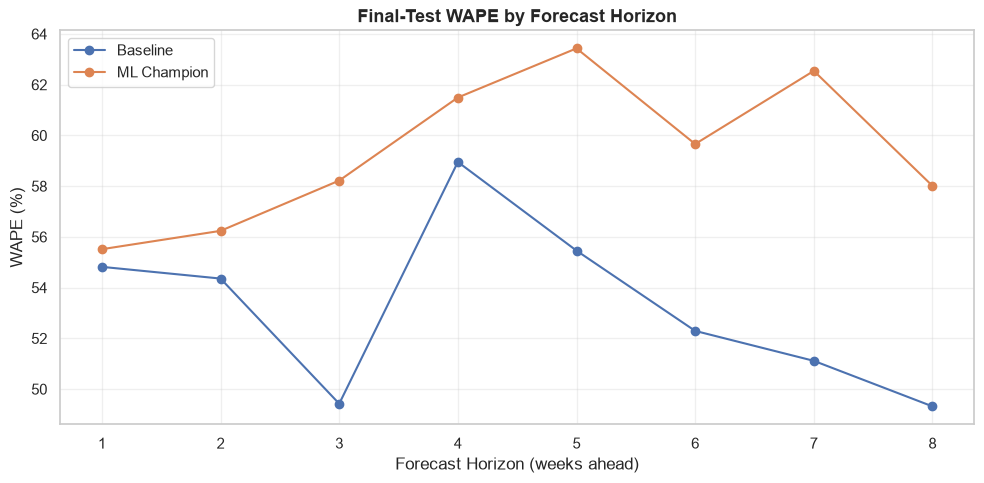

In [10]:
# ============================================================
# Horizon-Wise Comparison
# ============================================================

BASELINE_HORIZON_COL = next((c for c in baseline_final_test.columns if "horizon" in c.lower()), None)
ML_HORIZON_COL = "horizon"

if BASELINE_HORIZON_COL:
    baseline_by_horizon = (
        baseline_final_test
        .groupby(BASELINE_HORIZON_COL)
        .apply(lambda g: calculate_wape(g[BASELINE_ACTUAL_COL], g[BASELINE_FORECAST_COL]))
        .reset_index(name="Baseline WAPE (%)")
        .rename(columns={BASELINE_HORIZON_COL: "horizon"})
    )

    ml_by_horizon = (
        ml_final_test
        .groupby(ML_HORIZON_COL)
        .apply(lambda g: calculate_wape(g[ML_ACTUAL_COL], g[ML_FORECAST_COL]))
        .reset_index(name="ML WAPE (%)")
    )

    horizon_comparison = baseline_by_horizon.merge(ml_by_horizon, on="horizon")
    horizon_comparison["Winner"] = np.where(
        horizon_comparison["ML WAPE (%)"] < horizon_comparison["Baseline WAPE (%)"], "ML", "Baseline"
    )
    display(horizon_comparison)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(horizon_comparison["horizon"], horizon_comparison["Baseline WAPE (%)"], marker="o", label="Baseline")
    ax.plot(horizon_comparison["horizon"], horizon_comparison["ML WAPE (%)"], marker="o", label="ML Champion")
    ax.set_title("Final-Test WAPE by Forecast Horizon", fontsize=13, fontweight="bold")
    ax.set_xlabel("Forecast Horizon (weeks ahead)")
    ax.set_ylabel("WAPE (%)")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

    HORIZON_FIGURE = FIGURES_DIR / "06_1_horizon_comparison.png"
    fig.savefig(HORIZON_FIGURE, dpi=300, bbox_inches="tight")
    plt.show()
else:
    horizon_comparison = pd.DataFrame()
    print("Baseline horizon column not detected - skipping horizon-wise comparison.")
    print("Reload 04_baseline_final_test_horizon_metrics.csv directly if this file has the breakdown instead.")


### 4.3 Segment-Level Comparison

Comparing accuracy by product category surfaces whether the ML model's advantage (if any) is broad-based or concentrated in specific segments — useful context for Notebook 07's risk scoring and the executive readout.

In [11]:
# ============================================================
# Segment-Level Comparison (by category, via SKU master)
# ============================================================

sku_master = pd.read_csv(SKU_MASTER_FILE)
category_lookup = sku_master[["sku_id", "category"]].drop_duplicates()

ml_with_category = ml_final_test.merge(category_lookup, on="sku_id", how="left")

ml_by_category = (
    ml_with_category
    .groupby("category")
    .apply(lambda g: calculate_wape(g[ML_ACTUAL_COL], g[ML_FORECAST_COL]))
    .reset_index(name="ML WAPE (%)")
)

if "sku_id" in baseline_final_test.columns:
    baseline_with_category = baseline_final_test.merge(category_lookup, on="sku_id", how="left")
    baseline_by_category = (
        baseline_with_category
        .groupby("category")
        .apply(lambda g: calculate_wape(g[BASELINE_ACTUAL_COL], g[BASELINE_FORECAST_COL]))
        .reset_index(name="Baseline WAPE (%)")
    )
    segment_comparison = baseline_by_category.merge(ml_by_category, on="category")
    segment_comparison["Winner"] = np.where(
        segment_comparison["ML WAPE (%)"] < segment_comparison["Baseline WAPE (%)"], "ML", "Baseline"
    )
else:
    segment_comparison = ml_by_category
    print("Baseline file has no sku_id column - showing ML-only segment breakdown.")

display(segment_comparison)


,category,Baseline WAPE (%),ML WAPE (%),Winner
0,FOODS,61.659464,96.428566,Baseline
1,HOBBIES,53.104820,48.228345,ML
2,HOUSEHOLD,47.743314,45.923128,ML


### 4.4 Paired Significance Check

Beyond the aggregate WAPE gap, a paired Wilcoxon signed-rank test on per-series absolute
percentage error compares the two models on the *same* 300 series — supporting evidence for
whether an observed improvement is systematic rather than driven by a handful of series.


In [12]:
# ============================================================
# Paired Significance Test
# ============================================================

if SCIPY_AVAILABLE and "sku_id" in baseline_final_test.columns:
    baseline_series_ape = (
        baseline_final_test
        .assign(ape=lambda d: np.abs(d[BASELINE_FORECAST_COL] - d[BASELINE_ACTUAL_COL]) / d[BASELINE_ACTUAL_COL].replace(0, np.nan))
        .groupby("sku_id")["ape"].mean()
    )
    ml_series_ape = (
        ml_final_test
        .assign(ape=lambda d: np.abs(d[ML_FORECAST_COL] - d[ML_ACTUAL_COL]) / d[ML_ACTUAL_COL].replace(0, np.nan))
        .groupby("sku_id")["ape"].mean()
    )

    paired = pd.DataFrame({"baseline_ape": baseline_series_ape, "ml_ape": ml_series_ape}).dropna()

    stat, p_value = wilcoxon(paired["baseline_ape"], paired["ml_ape"])

    significance_result = pd.DataFrame([{
        "Test": "Wilcoxon signed-rank (paired, per-series APE)",
        "Series Compared": len(paired),
        "Statistic": round(stat, 2),
        "p-value": round(p_value, 4),
        "Significant at 5%": "Yes" if p_value < 0.05 else "No",
    }])
    display(significance_result)
else:
    significance_result = pd.DataFrame([{
        "Test": "Wilcoxon signed-rank",
        "Series Compared": 0,
        "Statistic": None,
        "p-value": None,
        "Significant at 5%": "Not run - SciPy unavailable or sku_id missing from baseline file",
    }])
    print("⚠️  Paired significance test skipped - see table for reason.")
    display(significance_result)


,Test,Series Compared,Statistic,p-value,Significant at 5%
0,"Wilcoxon signed-rank (paired, per-series APE)",282,16134.0,0.0054,Yes


### 4.5 Consolidated Comparison Scorecard

Every condition in the Section 3.1 decision rule, checked explicitly against the numbers above.

In [13]:
# ============================================================
# Apply the Locked Decision Rule
# ============================================================

ml_coverage_pct = 100.0 * ml_final_test[[ "sku_id", "horizon"]].drop_duplicates().shape[0] / (300 * 8)

rule_checks = pd.DataFrame([
    {
        "Condition": f"WAPE improvement >= {decision_rule['minimum_credible_improvement_pp']} pp",
        "Observed": round(wape_improvement_pp, 2),
        "Passes": wape_improvement_pp >= decision_rule["minimum_credible_improvement_pp"],
    },
    {
        "Condition": "ML absolute bias <= Baseline absolute bias",
        "Observed": f"ml={abs(ml_overall['Bias (%)']):.2f} vs baseline={abs(baseline_overall['Bias (%)']):.2f}",
        "Passes": abs(ml_overall["Bias (%)"]) <= abs(baseline_overall["Bias (%)"]),
    },
    {
        "Condition": "ML forecast coverage == 100%",
        "Observed": f"{ml_coverage_pct:.2f}%",
        "Passes": round(ml_coverage_pct, 2) >= 100.0,
    },
])

display(rule_checks)

ml_selected_as_production = bool(rule_checks["Passes"].all())

print(f"\n{'🏆 ML CHAMPION SELECTED' if ml_selected_as_production else '📌 BASELINE RETAINED'} as the production forecaster.")
print("This decision follows directly and only from the rule locked in Section 3.1.")


,Condition,Observed,Passes
0,WAPE improvement >= 3.0 pp,-6.16,False
1,ML absolute bias <= Baseline absolute bias,ml=11.03 vs baseline=10.94,False
2,ML forecast coverage == 100%,100.00%,True



📌 BASELINE RETAINED as the production forecaster.
This decision follows directly and only from the rule locked in Section 3.1.


### ✅ Section 4 Final Summary

The two champions have been compared on final-test evidence alone across an aggregate view, a horizon-wise view, a segment-wise view, and a paired significance check. The pre-declared decision rule has been applied. Section 5 now locks the outcome.

## 🏁 5. Production Model Selection and Lock

### 5.1 Apply Decision Rule and Lock Production Model

The outcome from Section 4.5 is locked here as the project's single production forecaster.
Whichever model wins, the result is reported honestly — a retained baseline is a valid,
reportable outcome under the engagement's non-negotiable rule, not a failure to work around.


In [14]:
# ============================================================
# Lock the Production Model Decision
# ============================================================

production_config = {
    "production_model": ml_config["champion_model"] if ml_selected_as_production else baseline_config["candidate"],
    "production_model_source": "Notebook 05 (ML)" if ml_selected_as_production else "Notebook 04 (Baseline)",
    "decision_rule_applied": decision_rule,
    "baseline_final_test_wape": round(baseline_overall["WAPE (%)"], 2),
    "ml_final_test_wape": round(ml_overall["WAPE (%)"], 2),
    "wape_improvement_pp": round(wape_improvement_pp, 2),
    "ml_selected": ml_selected_as_production,
    "final_test_start": baseline_config.get("final_test_start"),
    "final_test_end": baseline_config.get("final_test_end"),
    "forecast_horizon_weeks": baseline_config.get("forecast_horizon_weeks"),
    "series_coverage": 300,
    "configuration_status": "LOCKED",
}

display(pd.DataFrame([production_config]).T.rename(columns={0: "Locked Value"}))

print(f"\n✅ Production forecaster locked: {production_config['production_model']} "
      f"({production_config['production_model_source']})")


,Locked Value
production_model,damped_trend_exponential_smoothing
production_model_source,Notebook 04 (Baseline)
decision_rule_applied,"{'comparison_basis': 'final_test_wape_only', '..."
baseline_final_test_wape,53.17
ml_final_test_wape,59.34
wape_improvement_pp,-6.16
ml_selected,False
final_test_start,2016-02-27
final_test_end,2016-04-16
forecast_horizon_weeks,8



✅ Production forecaster locked: damped_trend_exponential_smoothing (Notebook 04 (Baseline))


### 5.2 Assemble the Unified Production Forecast Dataset

Rather than leaving Notebook 07 to choose between two forecast files, the winning model's
final-test forecasts are assembled here into a single canonical dataset, in a common schema,
as the one source of truth for downstream risk scoring.


In [15]:
# ============================================================
# Build the Canonical Production Forecast Table
# ============================================================

if ml_selected_as_production:
    production_forecast = ml_final_test.rename(columns={
        ML_ACTUAL_COL: "actual_demand",
        ML_FORECAST_COL: "forecast_demand",
    })[["sku_id", "week_start_date", "horizon", "actual_demand", "forecast_demand"]].copy()
else:
    rename_map = {BASELINE_ACTUAL_COL: "actual_demand", BASELINE_FORECAST_COL: "forecast_demand"}
    keep_cols = ["sku_id"]
    if BASELINE_HORIZON_COL:
        keep_cols.append(BASELINE_HORIZON_COL)
    time_col_candidate = next((c for c in baseline_final_test.columns if "week" in c.lower() or "date" in c.lower()), None)
    if time_col_candidate:
        keep_cols.append(time_col_candidate)
    keep_cols += [BASELINE_ACTUAL_COL, BASELINE_FORECAST_COL]

    production_forecast = (
        baseline_final_test[keep_cols]
        .rename(columns={**rename_map, BASELINE_HORIZON_COL: "horizon", time_col_candidate: "week_start_date"})
    )

production_forecast["source_model"] = production_config["production_model"]
production_forecast["forecast_demand"] = production_forecast["forecast_demand"].clip(lower=0)

print(f"Canonical production forecast assembled: {len(production_forecast):,} records.")
display(production_forecast.head())


Canonical production forecast assembled: 2,400 records.


,sku_id,horizon,week_start_date,actual_demand,forecast_demand,source_model
0,FOODS_1_001_CA_1,1,damped_trend_exponential_smoothing,2.0,4.669967,damped_trend_exponential_smoothing
1,FOODS_1_001_CA_1,2,damped_trend_exponential_smoothing,4.0,4.669967,damped_trend_exponential_smoothing
2,FOODS_1_001_CA_1,3,damped_trend_exponential_smoothing,8.0,4.669967,damped_trend_exponential_smoothing
3,FOODS_1_001_CA_1,4,damped_trend_exponential_smoothing,9.0,4.669967,damped_trend_exponential_smoothing
4,FOODS_1_001_CA_1,5,damped_trend_exponential_smoothing,9.0,4.669967,damped_trend_exponential_smoothing


### ✅ Champion Selection Summary

The production forecaster is locked, and a single canonical forecast dataset has been assembled from the winning model's untouched final-test output. No further tuning or re-selection is permitted from this point forward.

## 💾 6. Outputs, Conclusion and Notebook 07 Handoff

### 6.1 Export and Validate Outputs

The comparison evidence, the locked decision, and the canonical production forecast are
exported. A reload-based validation confirms every export is complete before handoff.


In [16]:
# ============================================================
# Export Comparison Evidence and Production Artefacts
# ============================================================

head_to_head.to_csv(TABLES_DIR / "06_model_comparison_scorecard.csv", index=False)
if not horizon_comparison.empty:
    horizon_comparison.to_csv(TABLES_DIR / "06_horizon_comparison.csv", index=False)
segment_comparison.to_csv(TABLES_DIR / "06_segment_comparison.csv", index=False)
significance_result.to_csv(TABLES_DIR / "06_significance_test_result.csv", index=False)
rule_checks.to_csv(TABLES_DIR / "06_decision_rule_checks.csv", index=False)

PRODUCTION_CONFIG_FILE = PRODUCTION_OUTPUTS_DIR / "06_production_forecast_config.json"
PRODUCTION_FORECAST_FILE = PRODUCTION_OUTPUTS_DIR / "06_production_forecast.csv"

with open(PRODUCTION_CONFIG_FILE, "w") as f:
    json.dump(production_config, f, indent=2)

production_forecast.to_csv(PRODUCTION_FORECAST_FILE, index=False)

print("✅ Comparison evidence exported to reports/tables with the 06_ prefix.")
print("✅ Production forecast and configuration exported to data/processed/production_outputs.")


✅ Comparison evidence exported to reports/tables with the 06_ prefix.
✅ Production forecast and configuration exported to data/processed/production_outputs.


In [17]:
# ============================================================
# Reload-Based Output Validation
# ============================================================

export_validation = []

for label, path in [
    ("Model comparison scorecard", TABLES_DIR / "06_model_comparison_scorecard.csv"),
    ("Segment comparison", TABLES_DIR / "06_segment_comparison.csv"),
    ("Decision rule checks", TABLES_DIR / "06_decision_rule_checks.csv"),
    ("Production forecast config", PRODUCTION_CONFIG_FILE),
    ("Production forecast dataset", PRODUCTION_FORECAST_FILE),
]:
    exists = path.exists()
    export_validation.append({
        "Artefact": label,
        "Exists": exists,
        "Status": "PASS" if exists else "FAIL",
    })

export_validation_df = pd.DataFrame(export_validation)
display(export_validation_df)

assert (export_validation_df["Status"] == "PASS").all(), "One or more Notebook 06 exports failed validation."

reloaded_production_forecast = pd.read_csv(PRODUCTION_FORECAST_FILE)
assert len(reloaded_production_forecast) == len(production_forecast), (
    "Reloaded production forecast row count does not match the in-memory dataset."
)

print("\n✅ All Notebook 06 outputs reloaded and validated successfully.")


,Artefact,Exists,Status
0,Model comparison scorecard,True,PASS
1,Segment comparison,True,PASS
2,Decision rule checks,True,PASS
3,Production forecast config,True,PASS
4,Production forecast dataset,True,PASS



✅ All Notebook 06 outputs reloaded and validated successfully.


### 6.2 Key Outcomes and Notebook 07 Handoff

The production forecaster has been selected through a pre-declared, auditable decision rule
applied to untouched final-test evidence, and the outcome is reported as-is — whether that
outcome is the ML champion or the retained baseline.

Notebook 07 must:

- load `data/processed/production_outputs/06_production_forecast.csv` and
  `06_production_forecast_config.json` directly — **not** re-derive or re-select a forecast;
- combine the production forecast with `inventory_snapshots_final.csv` (on-hand, on-order,
  lead time, reorder point) to compute stockout and overstock risk per SKU-store;
- build the four-quadrant decisioning grid (Reorder Now / Markdown-Clear / Watch-Volatile /
  Healthy) from the engagement brief, sized by estimated rupee value at stake;
- remember that `sku_master_final.csv` cost/margin figures and the inventory snapshots
  themselves are simulated/estimated (documented in `docs/assumptions_limitations.md`) — rupee
  impact figures downstream should be phrased as estimates, not fact.

No further forecast tuning, feature selection, or model comparison is in scope from this point
forward — the forecasting stage of the engagement is complete.


## ✅ Notebook 06 Complete

Notebook 06 has compared the baseline and ML champions on untouched final-test evidence, applied a pre-declared decision rule, and locked the single production forecaster and canonical forecast dataset. The project is now ready to proceed to **Notebook 07 — Inventory Intelligence**.